In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

from scipy.stats import linregress
import DataProcessor

In [2]:
RUPTURE_POSITIONS = [115, 110, 105, 100, 95, 90, 85, 80, 75, 65, 55, 45, 35, 25, 15, 5]
STIFFNESSES = [500, 750, 1050, 1500, 2100, 3000, 4200, 6000, 8400, 12000, 30000]

E_AVERAGE = []
E_STD = []

G_AVERAGE = []
G_STD = []

G80_AVERAGE = []
G80_STD = []

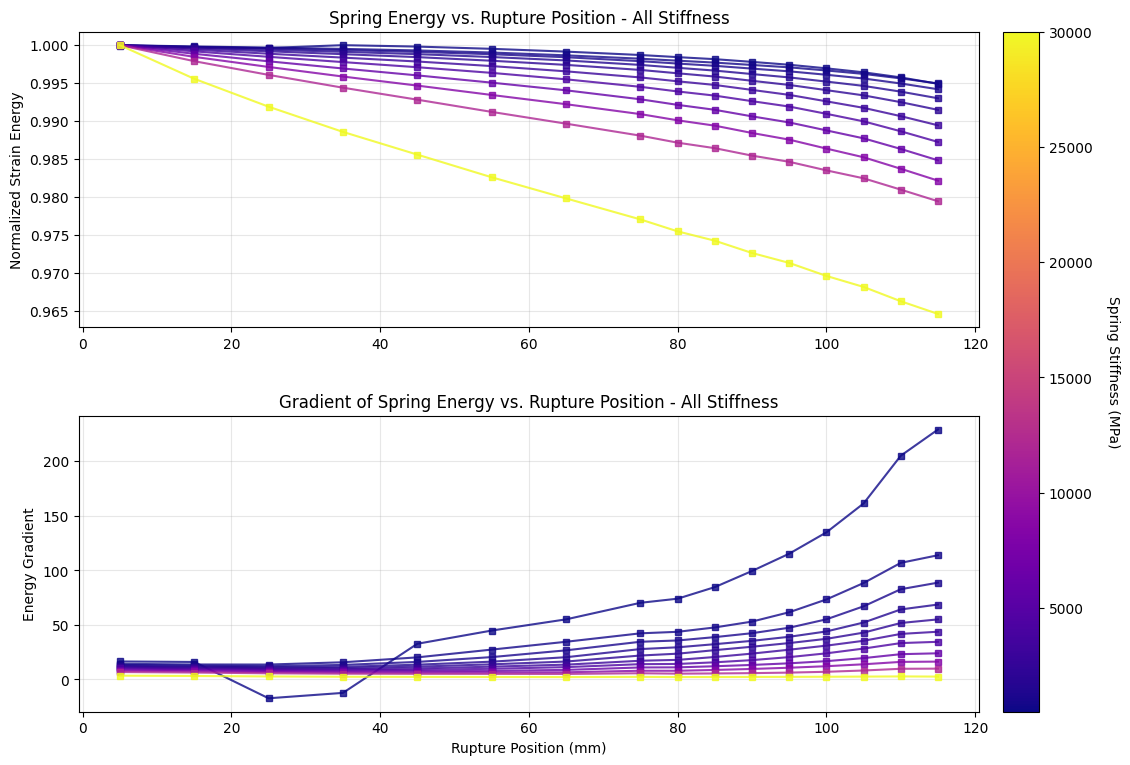

In [3]:
for STIFFNESS in STIFFNESSES:
    folder_path = f"./Stiffness/Y{STIFFNESS}"

    spring_energies = []

    for RUPTURE_POSITION in RUPTURE_POSITIONS:
        
        filename = f'strain-energy-{RUPTURE_POSITION}.npz'
        file_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_path):
            print(f"[WARNING] File {filename} not found. Skipping.")
            continue
        data = np.load(file_path)
        spring_energies.append(data.get('ELSE-Spring', np.nan))

    spring_energies = np.array(spring_energies)
    G_spring = -np.gradient(spring_energies, RUPTURE_POSITIONS)

    E_AVERAGE.append(np.mean(spring_energies))
    E_STD.append(np.std(spring_energies))

    G80_AVERAGE.append(G_spring[7])
    G_AVERAGE.append(np.mean(G_spring))
    G_STD.append(np.std(G_spring))

    if 'global_data' not in locals():
        global_data = []
    global_data.append({
        'mesh_size': STIFFNESS,
        'spring_energies': spring_energies,
        'G_spring': G_spring
    })

    plot_individual = True
    plot_Global = True
    if plot_individual:

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

        ax1.plot(RUPTURE_POSITIONS, spring_energies, 's-', label='Spring Energy')
        ax1.set_ylabel('Strain Energy')
        ax1.set_title(f'Spring Energy vs. Rupture Position, Displacement Control, E = {STIFFNESS}MPa')
        ax1.grid(True)
        ax1.legend()
        ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', label='Spring Energy Gradient', color='tab:orange')
        ax2.set_xlabel('Rupture Position (mm)')
        ax2.set_ylabel('Energy Gradient')
        ax2.set_title('Gradient of Spring Energy vs. Rupture Position')
        ax2.grid(True)
        ax2.legend()

        plt.tight_layout()
        plt.savefig(f'./MeshDC/Plots/DC-{STIFFNESS}MPa.pdf', dpi=300)
        # plt.show()
        plt.close()


if plot_Global:
    fig = plt.figure(figsize=(12, 8))
    
    ax1 = plt.subplot(2, 1, 1)
    ax2 = plt.subplot(2, 1, 2)
    
    sorted_data = sorted(global_data, key=lambda x: x['mesh_size'])
    mesh_sizes = [data['mesh_size'] for data in sorted_data]
    
    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=min(mesh_sizes), vmax=max(mesh_sizes))
    
    for data in sorted_data:
        mesh_size = data['mesh_size']
        spring_energies = data['spring_energies']
        G_spring = data['G_spring']
        
        color = cmap(norm(mesh_size))
        
        ax1.plot(RUPTURE_POSITIONS, spring_energies / np.max(spring_energies), 's-',  color=color, alpha=0.8, markersize=4, linewidth=1.5)
        # ax1.plot(RUPTURE_POSITIONS, spring_energies, 's-',  color=color, alpha=0.8, markersize=4, linewidth=1.5)
        ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', color=color, alpha=0.8, markersize=4, linewidth=1.5)
    
    ax1.set_ylabel('Normalized Strain Energy')
    # ax1.set_ylabel('Strain Energy')
    ax1.set_title('Spring Energy vs. Rupture Position - All Stiffness')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Rupture Position (mm)')
    ax2.set_ylabel('Energy Gradient')
    ax2.set_title('Gradient of Spring Energy vs. Rupture Position - All Stiffness')
    ax2.grid(True, alpha=0.3)
    ax2.sharex(ax1)
    
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.85, top=0.95, hspace=0.3)
    
    smap = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    smap.set_array([])
    cbar_ax = fig.add_axes([0.87, 0.1, 0.03, 0.85])
    cbar = fig.colorbar(smap, cax=cbar_ax)
    cbar.set_label('Spring Stiffness (MPa)', rotation=270, labelpad=20)
    
    plt.savefig('./Stiffness/Plots/DC-Global-All-Stiffness.pdf', dpi=300)
    plt.savefig('./Stiffness/Plots/PNG/DC-Global-All-Stiffness.png', dpi=300)
    plt.show()
    plt.close()


STIFFNESSES = np.array(STIFFNESSES)
G_AVERAGE = np.array(G_AVERAGE)
G80_AVERAGE = np.array(G80_AVERAGE)
G_STD     = np.array(G_STD)

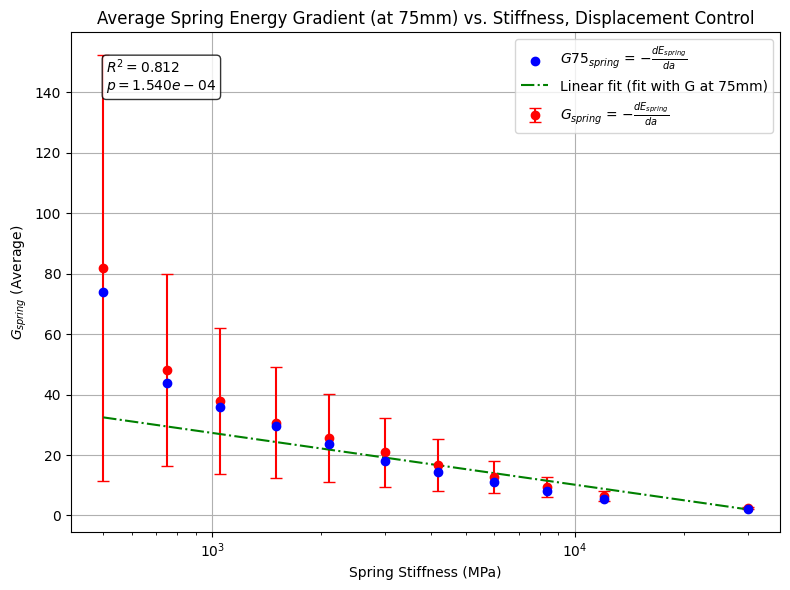

In [4]:
slope, intercept, r_value, p_value, std_err = linregress(np.log10(STIFFNESSES), G80_AVERAGE)
slope, intercept = DataProcessor.get_linear_regression(np.log10(STIFFNESSES), G80_AVERAGE, np.ones_like(STIFFNESSES), G_STD, slope, intercept)

fig, ax = plt.subplots(figsize=(8, 6))

# ax.errorbar(STIFFNESSES, G80_AVERAGE, yerr=G_STD, fmt='o', capsize=4, label=r'$G75_{spring}$ = $\frac{dE_{spring}}{da}$')
ax.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, color='red', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')

ax.scatter(STIFFNESSES, G80_AVERAGE, color='blue', label=r'$G75_{spring}$ = $-\frac{dE_{spring}}{da}$', marker='o', zorder = 3)

x_fit = np.linspace(min(np.log10(STIFFNESSES)), max(np.log10(STIFFNESSES)), 100)
y_fit = slope * x_fit + intercept
ax.plot(10**x_fit, y_fit, '-.', color = "green", label='Linear fit (fit with G at 75mm)')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Spring Stiffness (MPa)')
ax.set_ylabel(r'$G_{spring}$ (Average)')
ax.legend()
ax.grid(True)
plt.title('Average Spring Energy Gradient (at 75mm) vs. Stiffness, Displacement Control')
plt.xscale("log")
plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G75.pdf', dpi=300)
plt.show()
plt.close()

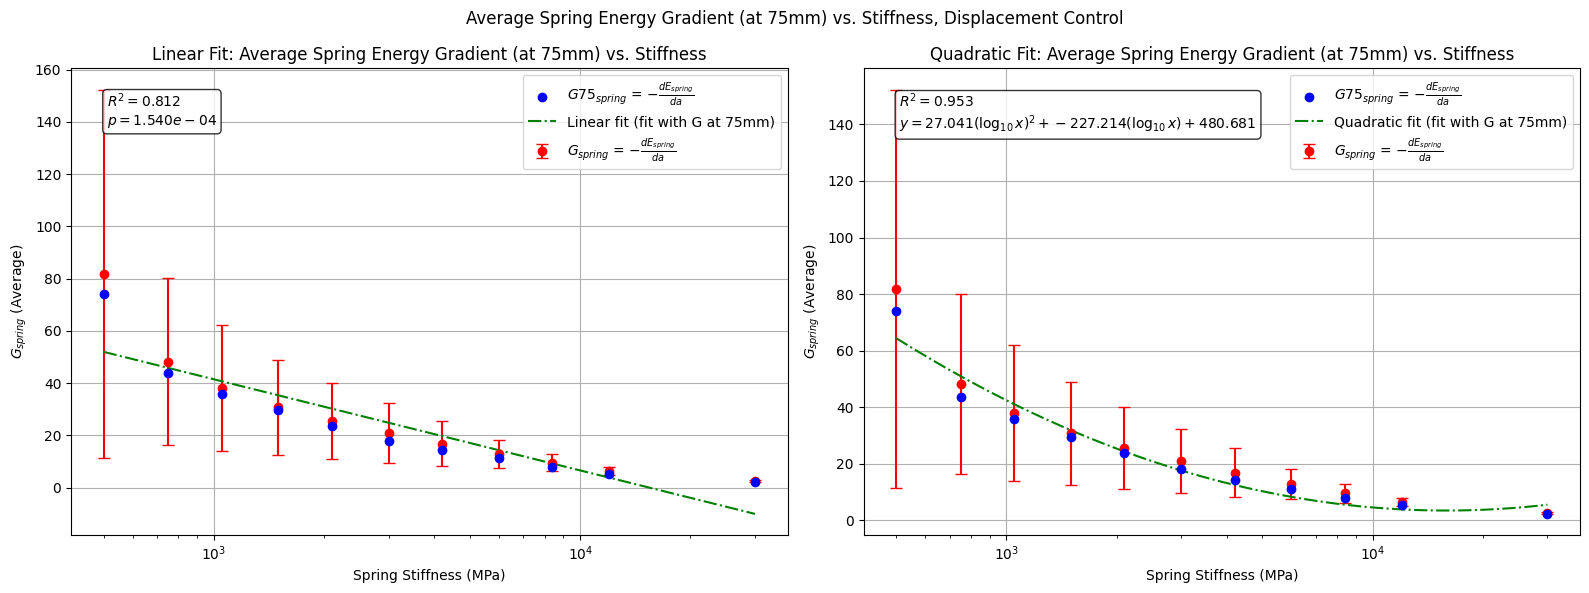

In [5]:
slope, intercept, r_value, p_value, std_err = linregress(np.log10(STIFFNESSES), G80_AVERAGE)
# slope, intercept = DataProcessor.get_linear_regression(np.log10(STIFFNESSES), G80_AVERAGE, np.ones_like(STIFFNESSES), G_STD, slope, intercept)

# 二次函數擬合
log_stiffnesses = np.log10(STIFFNESSES)
quadratic_coeffs = np.polyfit(log_stiffnesses, G80_AVERAGE, 2)
quadratic_poly = np.poly1d(quadratic_coeffs)

# 計算二次擬合的 R²
y_pred_quad = quadratic_poly(log_stiffnesses)
ss_res_quad = np.sum((G80_AVERAGE - y_pred_quad) ** 2)
ss_tot_quad = np.sum((G80_AVERAGE - np.mean(G80_AVERAGE)) ** 2)
r_squared_quad = 1 - (ss_res_quad / ss_tot_quad)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左圖：線性擬合
ax1.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, color='red', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
ax1.scatter(STIFFNESSES, G80_AVERAGE, color='blue', label=r'$G75_{spring}$ = $-\frac{dE_{spring}}{da}$', marker='o', zorder=3)

x_fit = np.linspace(min(np.log10(STIFFNESSES)), max(np.log10(STIFFNESSES)), 100)
y_fit = slope * x_fit + intercept
ax1.plot(10**x_fit, y_fit, '-.', color="green", label='Linear fit (fit with G at 75mm)')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'

ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('Spring Stiffness (MPa)')
ax1.set_ylabel(r'$G_{spring}$ (Average)')
ax1.legend()
ax1.grid(True)
ax1.set_title('Linear Fit: Average Spring Energy Gradient (at 75mm) vs. Stiffness')
ax1.set_xscale("log")

# 右圖：二次擬合
ax2.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, color='red', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
ax2.scatter(STIFFNESSES, G80_AVERAGE, color='blue', label=r'$G75_{spring}$ = $-\frac{dE_{spring}}{da}$', marker='o', zorder=3)

x_fit_quad = np.linspace(min(log_stiffnesses), max(log_stiffnesses), 100)
y_fit_quad = quadratic_poly(x_fit_quad)
ax2.plot(10**x_fit_quad, y_fit_quad, '-.', color="green", label='Quadratic fit (fit with G at 75mm)')

textstr_quad = f'$R^2 = {r_squared_quad:.3f}$\n$y = {quadratic_coeffs[0]:.3f}x^2 + {quadratic_coeffs[1]:.3f}x + {quadratic_coeffs[2]:.3f}$'
textstr_quad = f'$R^2 = {r_squared_quad:.3f}$\n$y = {quadratic_coeffs[0]:.3f}(\\log_{{10}}x)^2 + {quadratic_coeffs[1]:.3f}(\\log_{{10}}x) + {quadratic_coeffs[2]:.3f}$'

ax2.text(0.05, 0.95, textstr_quad, transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('Spring Stiffness (MPa)')
ax2.set_ylabel(r'$G_{spring}$ (Average)')
ax2.legend()
ax2.grid(True)
ax2.set_title('Quadratic Fit: Average Spring Energy Gradient (at 75mm) vs. Stiffness')
ax2.set_xscale("log")

plt.suptitle('Average Spring Energy Gradient (at 75mm) vs. Stiffness, Displacement Control')
plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G75-comparison.pdf', dpi=300)
plt.show()
plt.close()

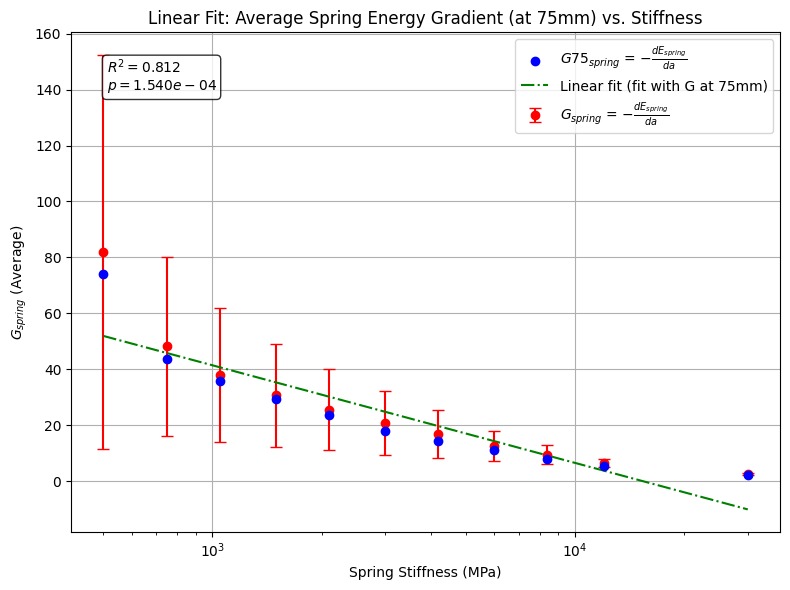

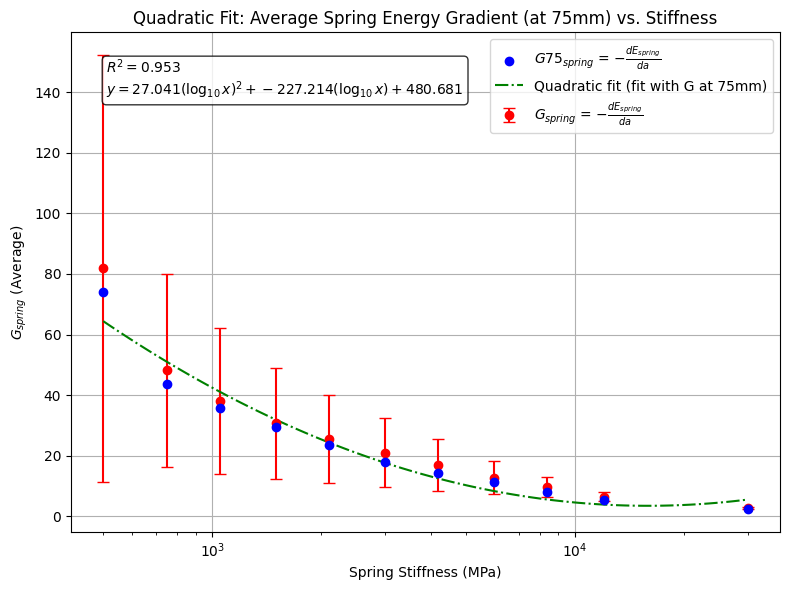

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, color='red', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
ax1.scatter(STIFFNESSES, G80_AVERAGE, color='blue', label=r'$G75_{spring}$ = $-\frac{dE_{spring}}{da}$', marker='o', zorder=3)

x_fit = np.linspace(min(np.log10(STIFFNESSES)), max(np.log10(STIFFNESSES)), 100)
y_fit = slope * x_fit + intercept
ax1.plot(10**x_fit, y_fit, '-.', color="green", label='Linear fit (fit with G at 75mm)')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('Spring Stiffness (MPa)')
ax1.set_ylabel(r'$G_{spring}$ (Average)')
ax1.legend()
ax1.grid(True)
ax1.set_title('Linear Fit: Average Spring Energy Gradient (at 75mm) vs. Stiffness')
ax1.set_xscale("log")

plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G75-linear.pdf', dpi=300)
plt.savefig('./Stiffness/Plots/PNG/DC-Stiffness-G75-linear.png', dpi=300)
plt.show()
plt.close()


# 二次擬合圖
fig, ax2 = plt.subplots(figsize=(8, 6))

ax2.errorbar(STIFFNESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, color='red', 
             label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
ax2.scatter(STIFFNESSES, G80_AVERAGE, color='blue', 
            label=r'$G75_{spring}$ = $-\frac{dE_{spring}}{da}$', marker='o', zorder=3)

x_fit_quad = np.linspace(min(log_stiffnesses), max(log_stiffnesses), 100)
y_fit_quad = quadratic_poly(x_fit_quad)
ax2.plot(10**x_fit_quad, y_fit_quad, '-.', color="green", label='Quadratic fit (fit with G at 75mm)')

textstr_quad = f'$R^2 = {r_squared_quad:.3f}$\n$y = {quadratic_coeffs[0]:.3f}(\\log_{{10}}x)^2 + {quadratic_coeffs[1]:.3f}(\\log_{{10}}x) + {quadratic_coeffs[2]:.3f}$'
ax2.text(0.05, 0.95, textstr_quad, transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('Spring Stiffness (MPa)')
ax2.set_ylabel(r'$G_{spring}$ (Average)')
ax2.legend()
ax2.grid(True)
ax2.set_title('Quadratic Fit: Average Spring Energy Gradient (at 75mm) vs. Stiffness')
ax2.set_xscale("log")

plt.tight_layout()
plt.savefig('./Stiffness/Plots/DC-Stiffness-G75-quadratic.pdf', dpi=300)
plt.savefig('./Stiffness/Plots/PNG/DC-Stiffness-G75-quadratic.png', dpi=300)
plt.show()
plt.close()